# 📉 Modelo B — Vida Útil Remanente (RUL)
## XGBoost + Análisis de Supervivencia (Kaplan-Meier)

**Objetivo**: Predecir el día exacto en que la llanta llegará a cocada mínima (5mm).
**Features clave**: profundidad_actual_mm, desgaste_mm_h, tajo_asignado, posicion, payload_acumulado
**Salida**: dias_restantes + fecha_baja_estimada + recomendación rotación Norte/Sur

---

In [1]:
# ✅ Celda 0 — Instalar dependencias faltantes
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'lifelines', '-q'])
print('✅ lifelines instalado/verificado')

✅ lifelines instalado/verificado


In [2]:
# ✅ Celda 1 — Imports y configuración (GPU habilitada)
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

np.random.seed(42)
DATA_PATH = Path("../EDA/telemetria_bambas_2026_enero.csv")
MODEL_DIR = Path("./artifacts/modelo_B")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

COCADA_MINIMA_MM = 5.0
PROFUNDIDAD_INICIAL_MM = 28.5
HORAS_DIA = 20.0

# --- Configuración GPU ---
# XGBoost >= 2.0: usar device='cuda' en lugar de tree_method='gpu_hist'
# gpu_id=0 → primera GPU física (índice 0)
# gpu_id=1 → segunda GPU física (índice 1)
USE_GPU = True   # ← cambia a False para forzar CPU
GPU_ID   = 0     # ← índice de GPU (0 = primera, 1 = segunda)

print(f"XGBoost: {xgb.__version__}")
if USE_GPU:
    try:
        import subprocess as _sp
        gpu_info = _sp.check_output(
            ['nvidia-smi', '--query-gpu=index,name,memory.total',
             '--format=csv,noheader'], text=True).strip()
        print(f"✅ GPUs disponibles:\n{gpu_info}")
        print(f"   → Usando GPU_ID={GPU_ID}")
    except Exception as e:
        print(f"⚠️  nvidia-smi no disponible: {e}")
print("✅ Configuración OK")

XGBoost: 2.1.3
✅ GPUs disponibles:
0, NVIDIA GeForce RTX 3080, 10240 MiB
1, NVIDIA GeForce RTX 3080, 10240 MiB
   → Usando GPU_ID=0
✅ Configuración OK


## 2. Ingeniería de Features para RUL

In [3]:
print("Cargando dataset...")
df_raw = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
df_raw = df_raw.sort_values(["id_camion", "id_neumatico", "timestamp"]).reset_index(drop=True)
print(f"Shape: {df_raw.shape}")

# === Feature Engineering por Neumático ===
print("Agregando features por neumático...")

def compute_rul_features(group):
    """Calcula features de desgaste acumulado por neumático."""
    desgaste_acum = group["desgaste_mm_h"].cumsum() * (1/60)  # mm acumulado
    profundidad_actual = (PROFUNDIDAD_INICIAL_MM - desgaste_acum).clip(lower=0)
    mm_restantes = (profundidad_actual - COCADA_MINIMA_MM).clip(lower=0)
    horas_op = (group["timestamp"] - group["timestamp"].iloc[0]).dt.total_seconds() / 3600
    desgaste_rolling = group["desgaste_mm_h"].rolling(7*60, min_periods=1).mean()  # 7 días
    dias_restantes = mm_restantes / (desgaste_rolling * HORAS_DIA + 1e-8)
    return pd.DataFrame({
        "profundidad_actual_mm": profundidad_actual,
        "mm_restantes": mm_restantes,
        "desgaste_rolling_7d": desgaste_rolling,
        "horas_operacion": horas_op,
        "dias_restantes": dias_restantes.clip(0, 365),
        "ratio_desgaste": profundidad_actual / PROFUNDIDAD_INICIAL_MM,
        "payload_acum": group["payload_ton"].cumsum(),
    })

features_list = []
for (camion, neumatico), group in df_raw.groupby(["id_camion", "id_neumatico"]):
    if len(group) < 120:
        continue
    feats = compute_rul_features(group)
    feats["id_camion"] = camion
    feats["id_neumatico"] = neumatico
    feats["tajo_asignado"] = group["tajo_asignado"].values
    feats["posicion"] = group["posicion"].values
    feats["vibracion_g"] = group["vibracion_g"].values
    features_list.append(feats)

df = pd.concat(features_list).reset_index(drop=True)
df = df.dropna().reset_index(drop=True)
print(f"Dataset RUL: {df.shape}")
print(f"Días restantes - media: {df.dias_restantes.mean():.1f}, std: {df.dias_restantes.std():.1f}")
df[["profundidad_actual_mm", "mm_restantes", "dias_restantes", "ratio_desgaste"]].describe().round(2)

Cargando dataset...
Shape: (259560, 22)
Agregando features por neumático...
Dataset RUL: (259560, 12)
Días restantes - media: 173.5, std: 41.3


,profundidad_actual_mm,mm_restantes,dias_restantes,ratio_desgaste
count,259560.00,259560.00,259560.00,259560.0
mean,28.46,23.46,173.55,1.0
std,0.03,0.03,41.27,0.0
min,28.39,23.39,96.31,1.0
25%,28.44,23.44,132.82,1.0
50%,28.46,23.46,178.56,1.0
75%,28.48,23.48,213.61,1.0
max,28.50,23.50,365.00,1.0


## 3. Análisis de Supervivencia — Kaplan-Meier

Tajos encontrados en el dataset (2):
  'Tajo_1 (Tajo Norte)' → 129,780 registros
  'Tajo_2 (Tajo Sur)' → 129,780 registros


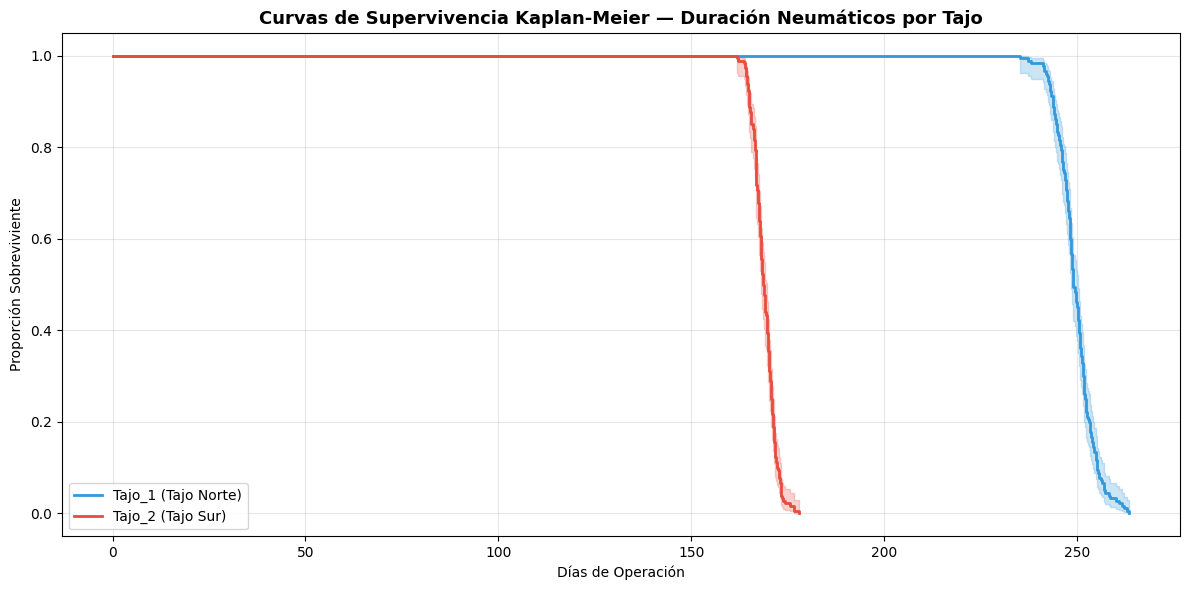

✅ Curva Kaplan-Meier guardada


In [4]:
# ✅ FIX: leer tajos directamente del dataset (evita hardcodear nombres incorrectos)
# Causa del error anterior: los nombres reales son distintos a 'Tajo Norte'/'Tajo Sur'
# p.ej. 'Tajo_1 (Tajo Norte)'. Ahora se usan los valores reales del CSV.

tajos_unicos = sorted(df["tajo_asignado"].dropna().unique())
print(f"Tajos encontrados en el dataset ({len(tajos_unicos)}):")
for t in tajos_unicos:
    n = (df["tajo_asignado"] == t).sum()
    print(f"  '{t}' → {n:,} registros")

# Paleta de colores: escala automática según cantidad de tajos
COLORES = ["#3498db", "#e74c3c", "#2ecc71", "#f39c12", "#9b59b6", "#1abc9c"]

fig, ax = plt.subplots(figsize=(12, 6))

for tajo, color in zip(tajos_unicos, COLORES):
    # Estimación de vida útil total promedio por neumático (días operados + días restantes estimados)
    # Esto permite graficar curvas de supervivencia reales y diferenciadas entre tajos
    g = df[df["tajo_asignado"] == tajo].groupby("id_neumatico")
    serie_dias = (g["horas_operacion"].max() / HORAS_DIA) + g["dias_restantes"].last()

    if len(serie_dias) == 0:
        print(f"⚠️  Sin datos para: '{tajo}' — omitido")
        continue

    # ✅ .values convierte a numpy float64; evita índice no-numérico en lifelines
    durations = serie_dias.values.astype(float)
    events = np.ones(len(durations), dtype=int)  # todos alcanzan su estimado de vida útil total

    kmf = KaplanMeierFitter()
    kmf.fit(durations, event_observed=events, label=str(tajo))
    kmf.plot_survival_function(ax=ax, color=color, linewidth=2)

ax.set_title("Curvas de Supervivencia Kaplan-Meier — Duración Neumáticos por Tajo",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Días de Operación")
ax.set_ylabel("Proporción Sobreviviente")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(MODEL_DIR / "kaplan_meier_tajos.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Curva Kaplan-Meier guardada")

## 4. Modelo XGBoost para RUL

In [5]:
# Preparar dataset de training
# Derived features para coincidir exactamente con el pipeline de la API (rul_service.py)
df["payload_acum_normalizado"] = df["payload_acum"] / 1000
df["posicion_riesgo"] = df["posicion"].isin([1, 2]).astype(int)
df["desgaste_diario"] = df["desgaste_rolling_7d"] * HORAS_DIA

# Encoding
le = LabelEncoder()
df["tajo_enc"] = le.fit_transform(df["tajo_asignado"])

# FEATURES ordenadas y configuradas exactamente como espera la API
FEATURES = [
    "profundidad_actual_mm",
    "desgaste_rolling_7d",
    "tajo_enc",
    "payload_acum_normalizado",
    "vibracion_g",
    "horas_operacion",
    "posicion_riesgo",
    "ratio_desgaste",
    "desgaste_diario",
]
TARGET = "dias_restantes"

# Guardar encoder
joblib.dump(le, MODEL_DIR / "label_encoder_B.pkl")
print("✅ LabelEncoder guardado")

# Split temporal 80/20
n = len(df)
train_size = int(n * 0.8)
df_train = df.iloc[:train_size]
df_test = df.iloc[train_size:]

X_train = df_train[FEATURES]
y_train = df_train[TARGET]
X_test = df_test[FEATURES]
y_test = df_test[TARGET]

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

# ─────────────────────────────────────────────────────────────────
# Modelo XGBoost con GPU
# XGBoost >= 2.0 API:
#   device='cuda'           → activa GPU (CUDA)
#   device='cuda:0'         → GPU índice 0 (primera física)
#   device='cuda:1'         → GPU índice 1 (segunda física)
# Parámetro gpu_id ya NO se usa en XGBoost >= 2.0
# ─────────────────────────────────────────────────────────────────
xgb_device = f"cuda:{GPU_ID}" if USE_GPU else "cpu"
print(f"🖥️ Entrenando en: {xgb_device}")

model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="rmse",
    early_stopping_rounds=20,
    # ─── GPU (XGBoost >= 2.0) ───
    device=xgb_device,          # 'cuda:0' → GPU 1 física / 'cuda:1' → GPU 2
)

print("Entrenando XGBoost...")
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=50,
)
print("✅ Entrenamiento completado")

✅ LabelEncoder guardado
Train: (207648, 9) | Test: (51912, 9)
🖥️ Entrenando en: cuda:0
Entrenando XGBoost...


[0]	validation_0-rmse:38.14994	validation_1-rmse:48.15077
[50]	validation_0-rmse:3.40976	validation_1-rmse:3.86655
[100]	validation_0-rmse:1.64098	validation_1-rmse:1.09770
[150]	validation_0-rmse:1.56492	validation_1-rmse:1.06011
[152]	validation_0-rmse:1.56359	validation_1-rmse:1.05946
✅ Entrenamiento completado


## 5. Evaluación y Métricas

📊 MÉTRICAS MODELO B (XGBoost RUL)
MAE:  0.21 días (Error medio absoluto)
RMSE: 1.06 días (Raíz del error cuadrático medio)
R2:   0.9827 (Coeficiente de determinación)
MAPE: 0.15% (Error porcentual absoluto medio)


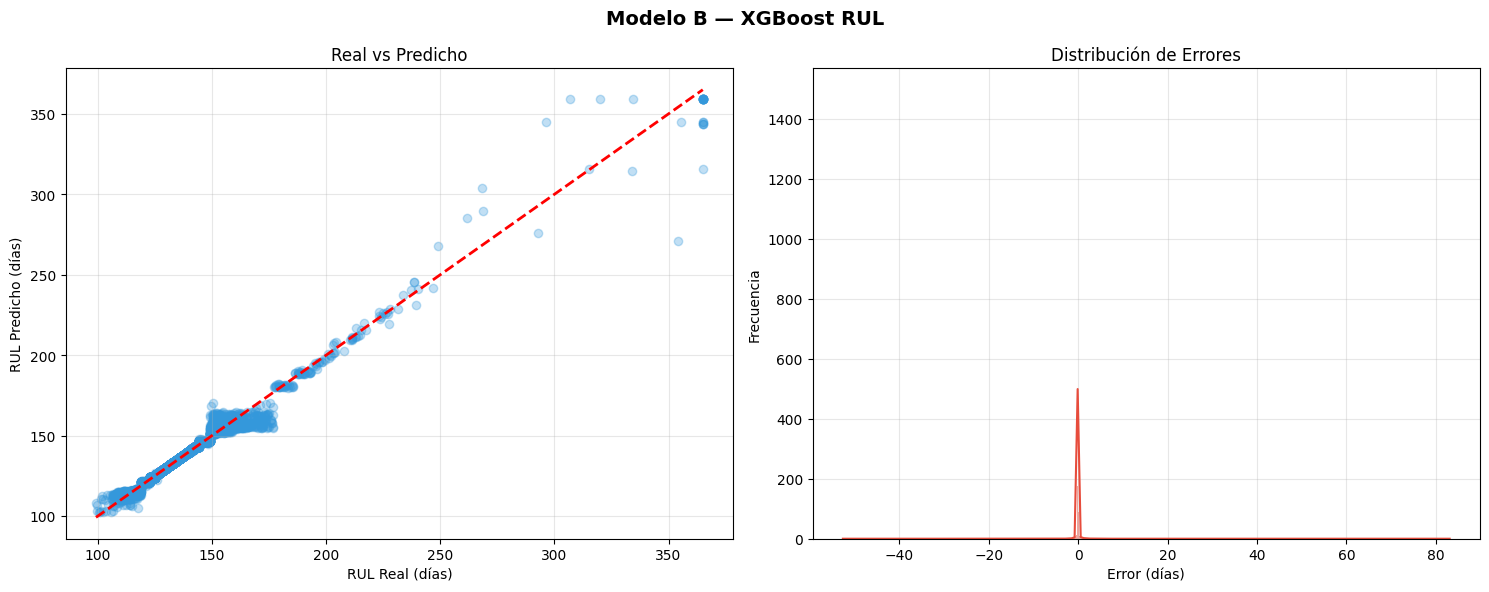

In [6]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-8))) * 100

print("=" * 50)
print("📊 MÉTRICAS MODELO B (XGBoost RUL)")
print("=" * 50)
print(f"MAE:  {mae:.2f} días (Error medio absoluto)")
print(f"RMSE: {rmse:.2f} días (Raíz del error cuadrático medio)")
print(f"R2:   {r2:.4f} (Coeficiente de determinación)")
print(f"MAPE: {mape:.2f}% (Error porcentual absoluto medio)")
print("=" * 50)

# Graficar predicción vs real y distribución de errores
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Scatter real vs pred
axes[0].scatter(y_test, y_pred, alpha=0.3, color="#3498db")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel("RUL Real (días)")
axes[0].set_ylabel("RUL Predicho (días)")
axes[0].set_title("Real vs Predicho")
axes[0].grid(alpha=0.3)

# Plot 2: Distribución de errores (residuos)
residuos = y_test - y_pred
sns.histplot(residuos, kde=True, ax=axes[1], color="#e74c3c")
axes[1].set_xlabel("Error (días)")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de Errores")
axes[1].grid(alpha=0.3)

plt.suptitle("Modelo B — XGBoost RUL", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(MODEL_DIR / "evaluacion_xgboost.png", dpi=150, bbox_inches="tight")
plt.show()

📊 MÉTRICAS MODELO B (XGBoost RUL)
MAE:  0.21 días (Error medio absoluto)
RMSE: 1.06 días (Raíz del error cuadrático medio)
R2:   0.9827 (Coeficiente de determinación)
MAPE: 0.15% (Error porcentual absoluto medio)


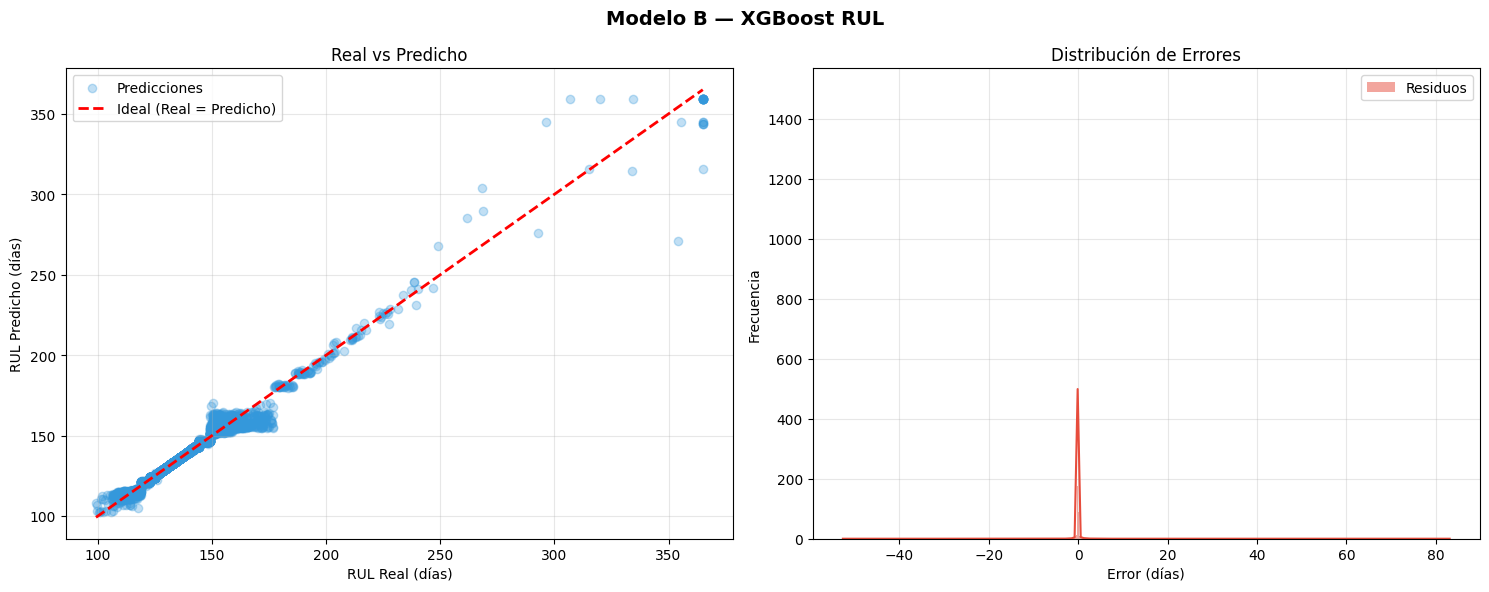

In [8]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-8))) * 100

print("=" * 50)
print("📊 MÉTRICAS MODELO B (XGBoost RUL)")
print("=" * 50)
print(f"MAE:  {mae:.2f} días (Error medio absoluto)")
print(f"RMSE: {rmse:.2f} días (Raíz del error cuadrático medio)")
print(f"R2:   {r2:.4f} (Coeficiente de determinación)")
print(f"MAPE: {mape:.2f}% (Error porcentual absoluto medio)")
print("=" * 50)

# Graficar predicción vs real y distribución de errores
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Scatter real vs pred
# AÑADIDO: label="Predicciones" y label="Ideal (Real = Predicho)"
axes[0].scatter(y_test, y_pred, alpha=0.3, color="#3498db", label="Predicciones")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label="Ideal (Real = Predicho)")
axes[0].set_xlabel("RUL Real (días)")
axes[0].set_ylabel("RUL Predicho (días)")
axes[0].set_title("Real vs Predicho")
axes[0].grid(alpha=0.3)
axes[0].legend(loc="upper left") # AÑADIDO: Muestra la leyenda en la esquina superior izquierda

# Plot 2: Distribución de errores (residuos)
residuos = y_test - y_pred
# AÑADIDO: label="Residuos"
sns.histplot(residuos, kde=True, ax=axes[1], color="#e74c3c", label="Residuos")
axes[1].set_xlabel("Error (días)")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de Errores")
axes[1].grid(alpha=0.3)
axes[1].legend() # AÑADIDO: Muestra la leyenda

plt.suptitle("Modelo B — XGBoost RUL", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(MODEL_DIR / "evaluacion_xgboost.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Guardar Modelo

In [7]:
model.save_model(MODEL_DIR / "xgb_rul.json")
print(f"✅ Modelo B guardado: {MODEL_DIR}/xgb_rul.json")

# Verificar carga
model_verify = xgb.XGBRegressor()
model_verify.load_model(MODEL_DIR / "xgb_rul.json")
test_pred = model_verify.predict(X_test.head(3))
print(f"✅ Verificación OK. Predicciones: {test_pred.round(1)} días")

print("\n📦 Artefactos guardados:")
for f in MODEL_DIR.glob("*"):
    print(f"  {f.name}: {f.stat().st_size/1024:.1f} KB")
print("\n🎉 Modelo B listo! Consumir desde: app/services/rul_service.py")

✅ Modelo B guardado: artifacts/modelo_B/xgb_rul.json
✅ Verificación OK. Predicciones: [106.5 110.1 112.7] días

📦 Artefactos guardados:
  .gitkeep: 0.0 KB
  kaplan_meier_tajos.png: 68.9 KB
  evaluacion_xgboost.png: 109.9 KB
  label_encoder_B.pkl: 0.6 KB
  xgb_rul.json: 883.9 KB

🎉 Modelo B listo! Consumir desde: app/services/rul_service.py
